# ML02: Logistic Regression

Unlike linear regression which predicts continuous values, logistic regression predicts probabilities that an input belongs to the classes given.

## Sigmoid Function

The core of logistic regression is the sigmoid function, defined as:

$$
\boxed{\sigma(z) = \frac{1}{1 + e^{-z}}}
$$

In [1]:
import numpy as np
import matplotlib.pyplot as plt

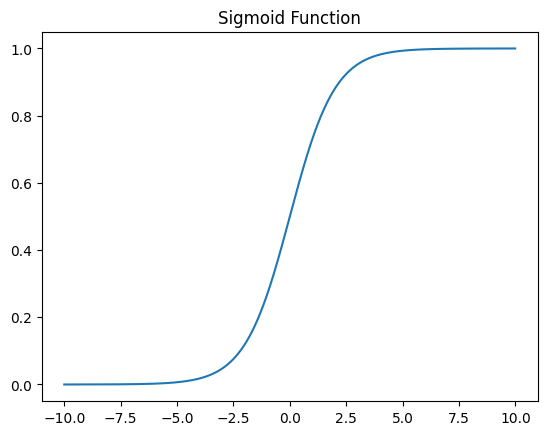

In [2]:
in_ = np.arange(-10, 10, 0.01)
out = 1 / (1 + np.exp(-in_))
plt.plot(in_, out)
plt.title("Sigmoid Function");

The sigmoid function takes in any real-valued inputs and outputs values between 0 and 1, making it suitable for interpreting outputs as probabilities.

## Hypothesis Function

Given input features $x = \begin{bmatrix} x_1 \\ x_2 \\ \vdots \\ x_n \end{bmatrix}$, logistic regression computes a linear combination:

$$
\begin{aligned}
z &= \theta_0 + \theta_1 x_1 + \theta_2 x_2 + \dots + \theta_n x_n \\
  &= \theta^T x
\end{aligned}
$$
*(Note: we define $x_0 = 1$ here.)*

The hypothesis function (predicted probability) is then:

$$
\boxed{h_\theta(x) = \sigma(\theta^T x) = \frac{1}{1 + \exp(-\theta^T x)}}
$$

## Likelihood Function

For a binary classification task ($y^{(i)} \in \{0, 1\}$), the probability model is defined as:

$$
\begin{aligned}
P(y^{(i)}=1|x^{(i)};\theta) &= h_\theta(x^{(i)}) \\
P(y^{(i)}=0|x^{(i)};\theta) &= 1 - h_\theta(x^{(i)})
\end{aligned}
$$

We can further express them in a single equation:

$$
P(y^{(i)}|x^{(i)};\theta) = (h_\theta(x^{(i)}))^{y^{(i)}} \cdot (1 - h_\theta(x^{(i)}))^{1-y^{(i)}}
$$

Similar to linear regression, the likelihood function is:

$$
L(\theta) = \prod_{i=1}^{m} {P(y^{(i)}|x^{(i)};\theta)}
$$

The log-likelihood function is then:

$$
\begin{aligned}
\ell(\theta) &= \ln \prod_{i=1}^{m} {P(y^{(i)}|x^{(i)};\theta)} \\
             &= \sum_{i=1}^{m} \ln\left((h_\theta(x^{(i)}))^{y^{(i)}} \cdot (1 - h_\theta(x^{(i)}))^{1-y^{(i)}}\right) \\
             &= \sum_{i=1}^{m} y^{(i)} \ln h_\theta(x^{(i)}) + \sum_{i=1}^{m} (1-y^{(i)}) \ln \left(1-h_\theta(x^{(i)})\right)
\end{aligned}
$$

Instead of maximizing $\ell(\theta)$, we <u>minimize</u> the negative log-likelihood, which leads to the cost function:

$$
J(\theta) = - \frac{1}{m} \ell(\theta)
$$

## Gradient Descent

To minimize the cost function, we use gradient descent:

$$
\theta \leftarrow \theta - \alpha\nabla J(\theta)
$$

where $\alpha$ is the learning rate.

$$
\begin{aligned}
\frac{\partial J(\theta)}{\partial \theta_j} &= -\frac{1}{m} \cdot \frac{\partial}{\partial \theta_j} \left(\sum_{i=1}^{m} y^{(i)} \ln h_\theta(x^{(i)}) + \sum_{i=1}^{m} (1-y^{(i)}) \ln \left(1-h_\theta(x^{(i)})\right)\right) \\
                                             &= -\frac{1}{m} \left(\sum_{i=1}^{m} {y^{(i)} \frac{\frac{\partial}{\partial \theta_j} h_\theta(x^{(i)})}{h_\theta(x^{(i)})} + \sum_{i=1}^{m} (1-y^{(i)}) \frac{- \frac{\partial}{\partial \theta_j} h_\theta(x^{(i)})}{1-h_\theta(x^{(i)})}} \right) \\
                                             &= -\frac{1}{m} \sum_{i=1}^{m} {\left(y^{(i)}\frac{1}{\sigma(\theta^T x^{(i)})} - (1-y^{(i)})\frac{1}{1-\sigma(\theta^T x^{(i)})}\right) \frac{\partial}{\partial \theta_j} \sigma(\theta^T x^{(i)})} 
\end{aligned}
$$

Using the chain rule:

$$
\begin{aligned}
\frac{\partial}{\partial \theta_j} \sigma(z) &= \frac{\partial}{\partial \theta_j} \left(1+\exp(-z)\right)^{-1} \\
                                             &= -\left(1+\exp(-z)\right)^{-2} \cdot -\exp(-z) \\
                                             &= \frac{\exp(-z)}{(1+\exp(-z))^2} \\
                                             &= \frac{1}{1+\exp(-z)} \cdot \frac{\exp(-z)+1-1}{1+\exp(-z)} \\
                                             &= \frac{1}{1+\exp(-z)} \cdot \left(1-\frac{1}{1+\exp(-z)}\right) \\
                                             &= \sigma(z) (1-\sigma(z)) \\
                                             &= \sigma(z) - \sigma^2(z)
\end{aligned}
$$

In the last module, we have shown that $\frac{\partial}{\partial \theta_j} \left(\theta^Tx^{(i)}\right) = x^{(i)}_j$. Combining together, we get:

$$
\begin{aligned}
\frac{\partial J(\theta)}{\partial \theta_j} &= -\frac{1}{m} \sum_{i=1}^{m} {\left(y^{(i)}\frac{1}{\sigma(\theta^T x^{(i)})} - (1-y^{(i)})\frac{1}{1-\sigma(\theta^T x^{(i)})}\right) \left(\sigma(\theta^Tx^{(i)}) - \sigma^2(\theta^Tx^{(i)})\right) x^{(i)}_j} \\
                                             &= -\frac{1}{m} \sum_{i=1}^{m} {\left(y^{(i)} - y^{(i)}\sigma(\theta^Tx^{(i)}) - \frac{\sigma(\theta^Tx^{(i)})-\sigma^2(\theta^Tx^{(i)})}{1-\sigma(\theta^Tx^{(i)})} + \frac{y^{(i)}\left(\sigma(\theta^Tx^{(i)})-\sigma^2(\theta^Tx^{(i)})\right)}{1-\sigma(\theta^Tx^{(i)})} \right) x^{(i)}_j} \\
                                             &= -\frac{1}{m} \sum_{i=1}^{m} {\left(y^{(i)} - y^{(i)}\sigma(\theta^Tx^{(i)}) - \sigma(\theta^Tx^{(i)}) + y^{(i)}\sigma(\theta^Tx^{(i)}) \right) x^{(i)}_j} \\
                                             &= -\frac{1}{m} \sum_{i=1}^{m} {\left(y^{(i)} - \sigma(\theta^Tx^{(i)}) \right) x^{(i)}_j}
\end{aligned}
$$

And finally:

$$
\boxed{\theta \leftarrow \theta + \alpha\frac{1}{m} \sum_{i=1}^{m} {\left(y^{(i)} - \sigma(\theta^Tx^{(i)}) \right) x^{(i)}_j}}
$$

## Multiclass Classification

### One-vs-Rest (OvR) Strategy

For a classification problem with $k$ classes ($y \in \{0,1,\dots,k\}$), we train $k$ separate binary logistic regression classifiers. Each classifier $h_\theta^{(j)}(x)$ is trained to distinguish class $j$ from all the others. Specifically, each classifier learns a separate parameter vector $\theta^{(j)}$.

After training all of the classifers, we classify a new input $x$ by choosing the class with the highest predicted probability:

$$
\hat{y} = \arg\underset{1\le j\le k}{\max} h_\theta^{(j)}(x)
$$

### Using Scikit-Learn

The implementation of the OvR model is almost identical to `BGDLinearRegression` from our previous module. The only difference is that labels is a matrix with dimensions $m\times k$. Therefore, we will focus directly on using Scikit-Learn here.

In [3]:
from sklearn.linear_model import LogisticRegression
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import seaborn as sns

In [4]:
iris_dataset = load_iris(as_frame=True)

iris_species = iris_dataset.target_names
X1, y1 = iris_dataset.data, iris_dataset.target
df_iris = X1.assign(**{"iris species": y1})
df_iris

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),iris species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,2
146,6.3,2.5,5.0,1.9,2
147,6.5,3.0,5.2,2.0,2
148,6.2,3.4,5.4,2.3,2


The Iris dataset is a famous dataset used for classification tasks. It contains 150 samples of iris flowers from three species:

- Setosa
- Versicolor
- Virginica

Each sample has four features (measurements in centimeters):

- Sepal length
- Sepal width
- Petal length
- Petal width

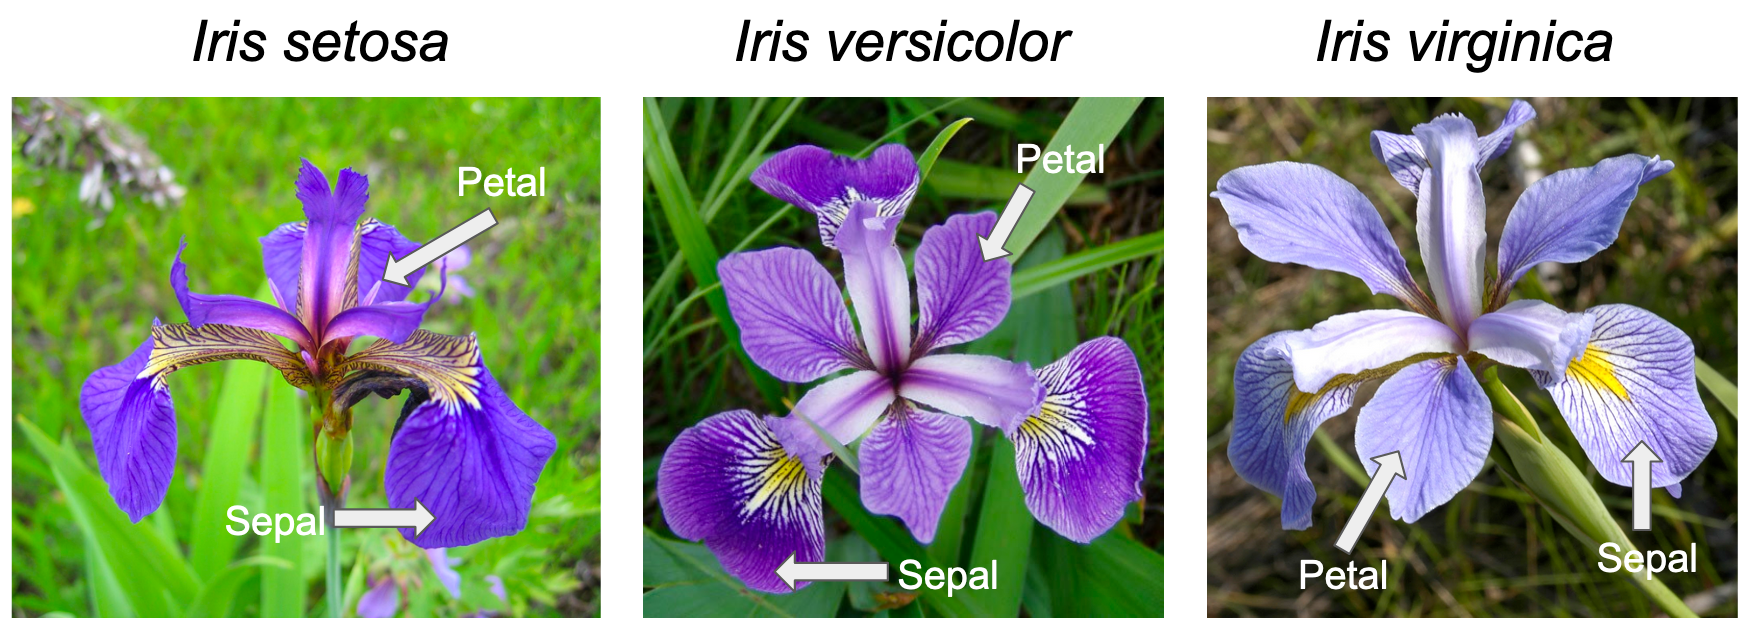
*(Image from the Internet)*



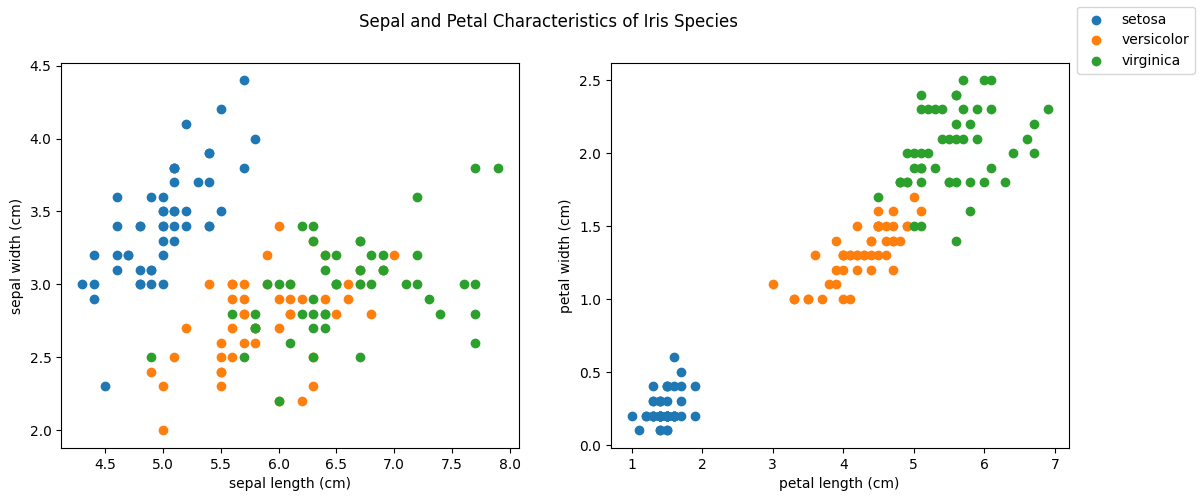

In [5]:
def scatter_iris(axes, x_column: str, y_column: str):
    for i in range(3):
        filtered = df_iris[df_iris["iris species"] == i]
        axes.scatter(filtered[x_column], filtered[y_column], label=iris_species[i])
        axes.set_xlabel(x_column)
        axes.set_ylabel(y_column)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
scatter_iris(axes[0], "sepal length (cm)", "sepal width (cm)")
scatter_iris(axes[1], "petal length (cm)", "petal width (cm)")
fig.legend(*axes[0].get_legend_handles_labels())
fig.suptitle("Sepal and Petal Characteristics of Iris Species");

From the graphs above, we can tell that the petal features provide a clearer separation of species than sepals. The points on the right show <u>a clear upward trend</u>: *setosa* forms a distinct cluster with short, narrow petals, while *versicolor* and *virginica* exhibit a clear progression in size, with *virginica* having the largest petals.

This pattern in the scatter plot relates to the concept of **correlation**.

> As petal length increases, petal width also increases.

This indicates a strong correlation between these two features, making them useful for logistic regression.

### Correlation

The correlation of two random variables $X$ and $Y$ is computed as follows:

$$
\boxed{\mathrm{corr}(X, Y) = \frac{\mathrm{cov}(X, Y)}{\sigma_X \sigma_Y} = \frac{\sum(X -\overline{X})(Y-\overline{Y})}{\sqrt{\sum(X-\overline{X})^2} \sqrt{\sum (Y-\overline{Y})^2}}}
$$

Correlation ranges from -1 to 1:

- -1 indicates a perfect negative correlation, meaning one feature increases as the other decreases.
- 0 indicates no linear relationship.
- 1 indicates a perfect positive correlation, meaning both features increase together.

From this, we can infer that the correlation between sepal length and width is close to 0, while the correlation between petal length and width is close to 1. Let us verify:

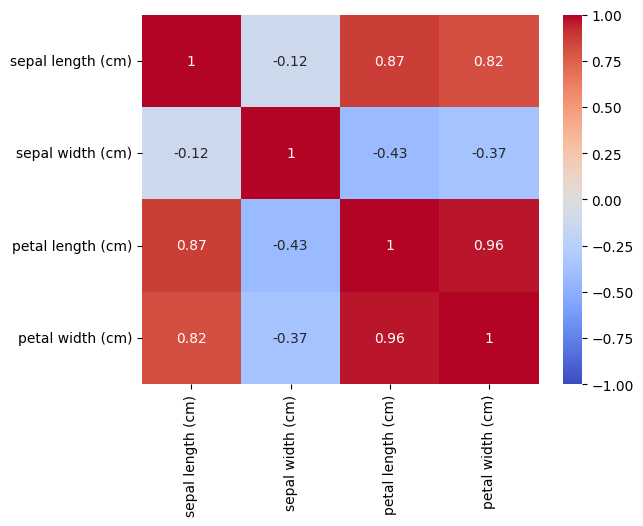

In [6]:
sns.heatmap(df_iris[df_iris.columns[:-1]].corr(), annot=True, vmin=-1, vmax=1, cmap='coolwarm');

Our inference is confirmed. We now proceed to train the model.

In [7]:
scaler = StandardScaler()
X1_scaled = scaler.fit_transform(X1)
X1_train, X1_test, y1_train, y1_test = train_test_split(X1_scaled, y1, train_size=0.15, random_state=42)

log_reg1 = LogisticRegression()
log_reg1.fit(X1_train, y1_train)

LogisticRegression()

For demonstration purposes, we set the train size to a very small value (0.15). The model achieves 100% accuracy on the test set with the default train size.

In [8]:
y1_pred = log_reg1.predict(X1_test)

### Metrics

#### Confusion Matrix

In a confusion matrix, each row represents the actual class, and each column represents the predicted class:

| Actual \ Predicted | Predicted A | Predicted B | Predicted C |
|-------------------|------------|------------|------------|
| **Actual A**      | TP(A)      | F(A→B)    | F(A→C)    |
| **Actual B**      | F(B→A)    | TP(B)      | F(B→C)    |
| **Actual C**      | F(C→A)    | F(C→B)    | TP(C)      |

where:

- TP(X): True Positives for class X (correct predictions).
- F(X→Y): False Positives for class Y, False Negatives for class X (misclassifications of X as Y).

Each entry in the matrix represents the number of samples classified into that category. Ideally, we want most values to be on the diagonal (correct classifications), with other values as small as possible.

In [9]:
from sklearn.metrics import *

confusion_matrix(y1_test, y1_pred)

array([[44,  1,  0],
       [ 0, 29, 14],
       [ 0,  1, 39]], dtype=int64)

#### Accuracy

Accuracy measures the proportion of correctly classified instances:

$$
\boxed{\mathrm{Accuracy} = \frac{\sum TP}{\sum \mathrm{Samples}}}
$$

It works best when classes are balanced.

In [10]:
accuracy_score(y1_test, y1_pred)

0.875

#### Precision

Precision measures how many predicted instances of a class are actually correct:

$$
\boxed{\mathrm{Precision\ for\ class\ X} = \frac{TP(X)}{TP(X) + \sum FP(X)}}
$$

High precision means fewer false positives.

In [11]:
precision_score(y1_test, y1_pred, average=None)

array([1.        , 0.93548387, 0.73584906])

#### Recall

Recall measures how many actual instances of a class were correctly classified:

$$
\boxed{\mathrm{Recall\ for\ class\ X} = \frac{TP(X)}{TP(X) + \sum FN(X)}}
$$

High recall means fewer false negatives.

In [12]:
recall_score(y1_test, y1_pred, average=None)

array([0.97777778, 0.6744186 , 0.975     ])

##### FP v.s. FN

| Scenario                     | False Negative (FN) | False Positive (FP) | Which is More Serious? |
|------------------------------|---------------------|---------------------|------------------------|
| **Fraud Detection** (e.g., credit card fraud) | Fraudulent transaction goes undetected | Legitimate transaction flagged as fraud | FN – Financial loss due to undetected fraud |
| **Airport Security Screening** | Dangerous item is missed | Harmless item is flagged | FN – Security risk if threats go undetected |
| **Spam Detection** | Important email is lost in spam | Spam email appears in inbox | FP – Losing important emails can be problematic |
| **Autonomous Vehicles** (e.g., obstacle detection) | Obstacle is not detected, collision risk | Car stops unnecessarily | FP – Unreliable braking can cause traffic issues |


#### F1 Score

In many real-world scenarios, we need a balance between precision and recall. The F1-score provides a single metric that captures this tradeoff, calculated as the harmonic mean of precision and recall:

$$
\boxed{\mathrm{F1} = 2 \times \frac{\mathrm{Precision}\times\mathrm{Recall}}{\mathrm{Precision}+\mathrm{Recall}}}
$$

The harmonic mean assigns greater influence to lower values and penalizes imbalances.

For multiclass classification, we often compute macro-averaged (equal weight for each class) or weighted-averaged (weighted by class frequency) versions of these metrics.

In [13]:
# Our classes are balanced, choosing between 'weighted' and 'macro' does not make a significant difference here.
f1_score(y1_test, y1_pred, average='weighted')

0.8730114986089751

### Multinomial Strategy (Softmax Regression)

Instead of training multiple binary classifiers, multinomial strategy computes probability scores for all classes at once. This approach uses the **softmax function**, which converts raw scores (logits) into probabilities that sum to 1.

For a given input $x$ and $k$ classes, the probability of $x$ belongs to class $j$ is computed as:

$$
P(y^{(i)}=j|x^{(i)};\theta)=\frac{\exp(\theta_j^Tx^{(i)})} {\sum_{l=1}^{k} \exp(\theta_l^Tx^{(i)})}
$$

where $\theta = \begin{bmatrix} \theta_1^T \\ \theta_2^T \\ \dots \\ \theta_k^T \end{bmatrix}$. It has a dimension of $(k \times \mathrm{no.\ of\ features})$ and each row $\theta_j^T$ corresponds to the weight vector for class $j$.

The softmax function is widely used not only in logistic regression but also in neural networks and deep learning for classification tasks.

#### Likelihood Function

The likelihood function of softmax regression is defined as:

$$
L(\theta) = \prod_{i=1}^{m} \prod_{j=1}^{k} P(y^{(i)}=j|x;\theta)^{1\{y^{(i)}=j\}}
$$

where $1\{\cdot\}$ is the indicator function. It equals 1 when the condition inside the braces is true and 0 otherwise. This formulation ensures that for each sample $i$, only the probability corresponding to the actual class $y^{(i)}$ contributes to the product.

Taking the negative log-likelihood, we get:

$$
\ell(\theta) = \sum_{i=1}^{m} \sum_{j=1}^{k} 1\{y^{(i)}=j\} \ln P(y^{(i)}=j|x;\theta)
$$

Instead of maximizing $\ell(\theta)$, we <u>minimize</u> the negative log-likelihood, which leads to the cost function:

$$
J(\theta) = - \frac{1}{m} \ell(\theta)
$$

This is also known as the **cross-entropy loss**.

#### Gradient Descent

$$
\begin{aligned}
\frac{\partial J(\theta)}{\partial \theta_j} &= -\frac{1}{m} \cdot \frac{\partial}{\partial \theta_j} \left(\sum_{i=1}^{m} \sum_{j=1}^{k} 1\{y^{(i)}=j\} \ln \frac{\exp(\theta_j^Tx^{(i)})} {\sum_{l=1}^{k} \exp(\theta_l^Tx^{(i)})}\right) \\
                                             &= -\frac{1}{m} \sum_{i=1}^{m} \sum_{j=1}^{k} 1\{y^{(i)}=j\} \frac{\partial}{\partial \theta_j} \left(\theta_j^Tx^{(i)} - \ln \sum_{l=1}^{k} \exp(\theta_l^Tx^{(i)})\right) \\
                                             &= -\frac{1}{m} \sum_{i=1}^{m} \sum_{j=1}^{k} 1\{y^{(i)}=j\} \left(x^{(i)} - \frac{1}{\sum_{l=1}^{k} \exp(\theta_l^Tx^{(i)})} \cdot \exp(\theta_j^Tx^{(i)}) x^{(i)}\right) \\
                                             &= -\frac{1}{m} \sum_{i=1}^{m} x^{(i)} 1\{y^{(i)}=j\} \sum_{j=1}^{k} \left(1 - P(y^{(i)}=j|x^{(i)};\theta)  \right) \\
                                             &= -\frac{1}{m} \sum_{i=1}^{m} x^{(i)} 1\{y^{(i)}=j\} \left(1 - \sum_{j=1}^{k}P(y^{(i)}=j|x^{(i)};\theta) \right) \\
                                             &= -\frac{1}{m} \sum_{i=1}^{m} x^{(i)} \left(1\{y^{(i)}=j\} - P(y^{(i)}=j|x^{(i)};\theta) \right)
\end{aligned}
$$

Therefore:

$$
\boxed{\theta \leftarrow \theta + \alpha\frac{1}{m} \sum_{i=1}^{m} x^{(i)} \left(1\{y^{(i)}=j\} - P(y^{(i)}=j|x^{(i)};\theta) \right)}
$$


### Visualisation of Decision Boundaries

In [14]:
IRIS_FEATURE_X = "petal length (cm)"
IRIS_FEATURE_Y = "petal width (cm)"

X1_partial = X1[[IRIS_FEATURE_X, IRIS_FEATURE_Y]]
scaler_partial = StandardScaler()
X1_partial_scaled = scaler_partial.fit_transform(X1_partial)
log_reg2 = LogisticRegression(multi_class="multinomial")
log_reg2.fit(X1_partial_scaled, y1)

LogisticRegression(multi_class='multinomial')

> Important Notes:
>
> <div><img src=attachment:c39b2370-ea44-4729-9d1b-3e2e315d6f3d.png width="600"></div>
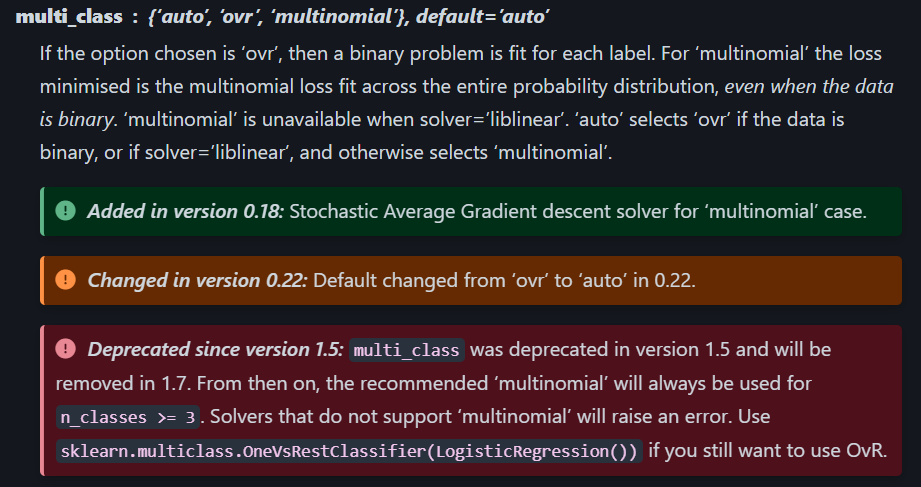

In [15]:
!pip show scikit-learn

Name: scikit-learn
Version: 1.3.2
Summary: A set of python modules for machine learning and data mining
Home-page: http://scikit-learn.org
Author: 
Author-email: 
License: new BSD
Location: c:\users\asus\appdata\local\packages\pythonsoftwarefoundation.python.3.8_qbz5n2kfra8p0\localcache\local-packages\python38\site-packages
Requires: joblib, numpy, scipy, threadpoolctl
Required-by: malaya


In [16]:
xx, yy = np.meshgrid(np.linspace(X1_partial[IRIS_FEATURE_X].min() - 0.1, X1_partial[IRIS_FEATURE_X].max() + 0.1, 500),
                     np.linspace(X1_partial[IRIS_FEATURE_Y].min() - 0.1, X1_partial[IRIS_FEATURE_Y].max() + 0.1, 500))

X1_partial_mesh = np.zeros((xx.ravel().shape[0], 2))
X1_partial_mesh[:, 0] = xx.ravel()
X1_partial_mesh[:, 1] = yy.ravel()
X1_partial_mesh_scaled = scaler_partial.transform(X1_partial_mesh)

C:\Users\ASUS\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.8_qbz5n2kfra8p0\LocalCache\local-packages\Python38\site-packages\sklearn\base.py:465: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


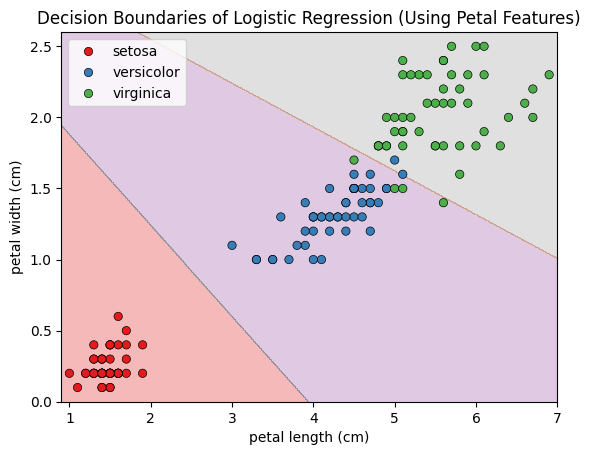

In [17]:
z = log_reg2.predict(X1_partial_mesh_scaled).reshape(xx.shape)

plt.contourf(xx, yy, z, alpha=0.3, cmap="Set1")
sns.scatterplot(x=X1_partial[IRIS_FEATURE_X], y=X1_partial[IRIS_FEATURE_Y], hue=iris_species[y1], palette="Set1", edgecolor="k")
plt.title("Decision Boundaries of Logistic Regression (Using Petal Features)")
plt.legend();

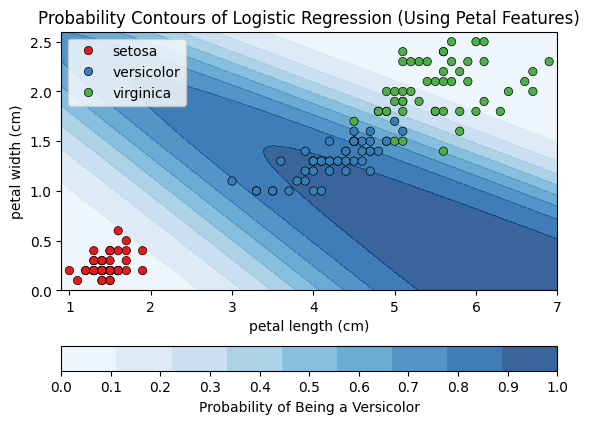

In [18]:
z1 = log_reg2.predict_proba(X1_partial_mesh_scaled)[:, 1].reshape(xx.shape)

plt.contourf(xx, yy, z1, cmap="Blues", levels=np.linspace(0, 1, 10), alpha=0.8)
plt.colorbar(ticks=np.arange(0, 1.1, 0.1), label="Probability of Being a Versicolor", orientation="horizontal")
sns.scatterplot(x=X1_partial[IRIS_FEATURE_X], y=X1_partial[IRIS_FEATURE_Y], hue=iris_species[y1], palette="Set1", edgecolor="k")
plt.title("Probability Contours of Logistic Regression (Using Petal Features)");

## Key Takeaways

- Logistic regression models the relationship between features and the probability of a binary outcome by applying a sigmoid function to a linear combination of the features. (`sklearn.linear_model.LogisticRegression`)
- Correlation measures the strength and direction of the linear relationship between two variables. (`pandas.DataFrame.corr`)
- Confusion matrix, accuracy, precision, recall, and F1 score are commonly used to evaluate the performance of classification models. (`sklearn.metrics.*`)
- In multiclass classification, two common approaches are OvR and multinomial.